In [8]:
from qiskit import QuantumCircuit
from qiskit import *
from qiskit.quantum_info import Statevector
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_aer import Aer
from qiskit.visualization import plot_bloch_multivector, visualize_transition, plot_histogram
from qiskit import transpile
from gates import I, X, Y, Z, H, P, S, T
from states import ket0, ket1, ket00, ket01, ket10, ket11

#CHSH Game

qc = QuantumCircuit(3, 2)
def bell_state():
    qc.h(0)
    qc.cx(0, 1)
    qc.measure(0, 1)
bell_state()
qc. cx(0, 2)
qc.h(2)
b = qc.measure(2,1)
a = qc.measure(0,0)
def classical_control():
    if a == 0:
        qc.x(1)
    if b == 1:
        qc.z(1)
classical_control()
qc.draw()








ModuleNotFoundError: No module named 'readline'

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
from qiskit_aer import AerSimulator
from qiskit import transpile
from gates import I, X, Y, Z, H, P, S, T
from states import ket0, ket1, ket00, ket01, ket10, ket11
'''qc = QuantumCircuit(1)
qc.h(0)
qc.z(0)
qc.h(0)
qc.measure_all()
qc.draw(output="text")
sim = AerSimulator()
t_qc = transpile(qc, sim)
result = sim.run(t_qc).result()
counts = result.get_counts()
print(counts)
#Translates to: 
composed_op = H @ Z @ H
hzh_result = composed_op @ ket0
print(hzh_result)'''



#X Gate
qc = QuantumCircuit(2)
qc.h(0)
qc.z(1)
qc.cx(0, 1)
qc.draw()

qc.measure_all()
qc.draw(output="text")
sim = AerSimulator()
t_qc = transpile(qc, sim)
result = sim.run(t_qc).result()
counts = result.get_counts()
print(counts)






{'00': 543, '11': 481}


In [ ]:
qc1 = QuantumCircuit(2)
qc1.h(0)
qc1.z(1)  # Happens "at the same time" as H, but does nothing to |0>
qc1.barrier()
qc1.cx(0, 1)
qc.draw()

┌───┐      ░ ┌─┐   
   q_0: ┤ H ├──■───░─┤M├───
        ├───┤┌─┴─┐ ░ └╥┘┌─┐
   q_1: ┤ Z ├┤ X ├─░──╫─┤M├
        └───┘└───┘ ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1

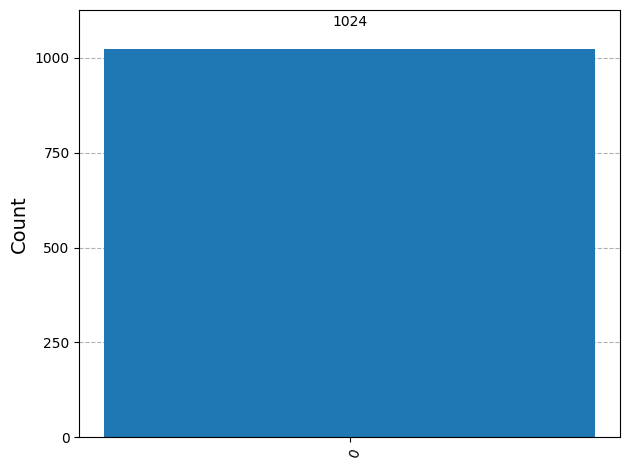

In [ ]:
#DJ Problem / Oracle Algorithm
import numpy as np
from qiskit.quantum_info import Statevector
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_aer import Aer
from qiskit import transpile
from gates import I, X, Y, Z, H, P, S, T
from qiskit.visualization import array_to_latex, plot_bloch_multivector, visualize_transition, plot_histogram

constant_oracle = QuantumCircuit(2)
output = np.random.randint(2)
if output == 1:
    constant_oracle.x(1)

constant_oracle.draw('mpl')

balanced_oracle = QuantumCircuit(2)
balanced_oracle.x(0)
balanced_oracle.barrier()
balanced_oracle.cx(0, 1)
balanced_oracle.barrier()
balanced_oracle.x(0)

balanced_oracle.draw('mpl')

dj_circuit = QuantumCircuit(2, 1)
dj_circuit.h(0)
dj_circuit.x(1)
dj_circuit.h(1)
oracle_fn = constant_oracle
#oracle_fn = balanced_oracle
dj_circuit.compose(oracle_fn, inplace=True)
dj_circuit.h(0)
dj_circuit.barrier()
dj_circuit.measure(0, 0)
dj_circuit.draw('mpl')
backend = Aer.get_backend('qasm_simulator')
shots = 1024
results = backend.run(dj_circuit, shots=shots).result()
answer = results.get_counts()

plot_histogram(answer)






In [ ]:
#Quantum Teleportation
qc = QuantumCircuit(1)
qc.s(0)
qc.s(0)
